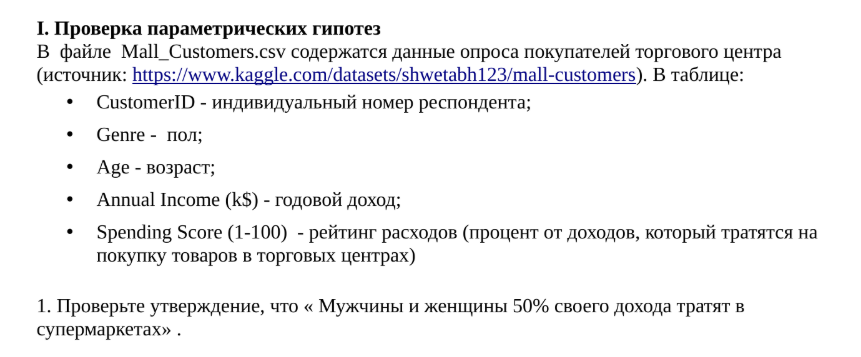

In [3]:
import numpy as np
import pandas as pd
from math import sqrt
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.stats.weightstats as stm


mall_df = pd.read_csv("Mall_Customers.csv", sep=",")
mall_df.columns = mall_df.columns.str.strip()
mall_df = mall_df.drop("CustomerID", axis=1)

display(mall_df)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


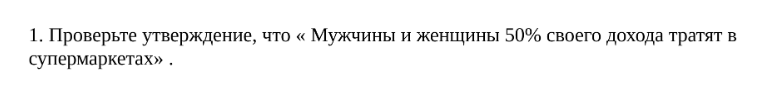

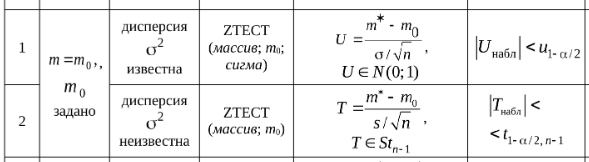

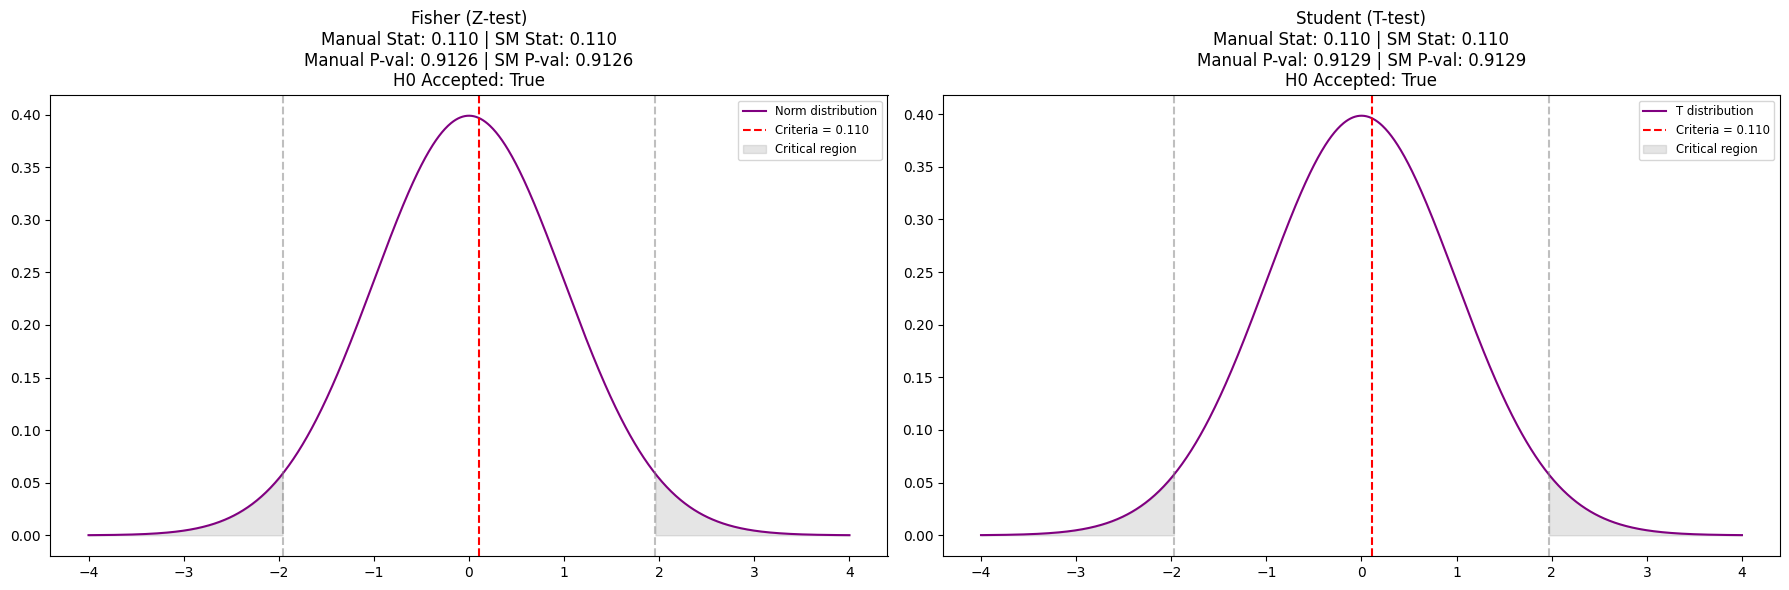

Global Stats -> Mean: 50.20, n: 200, Population Mean (H0): 50


In [4]:
ALPHA_P = 0.05
m_0 = 50
spending_score = mall_df["Spending Score (1-100)"]
n = spending_score.count()
mean = spending_score.mean()

# Define tests: (Title, ddof for std, distribution object, extra params)
tests = [
    ("Fisher (Z-test)", 0, stats.norm, {}),
    ("Student (T-test)", 1, stats.t, {"df": n - 1}),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (title, ddof, dist, params) in zip(axes, tests):
    # 1. Manual Calculation
    std = spending_score.std(ddof=ddof)
    se = std / sqrt(n)
    stat_val = (mean - m_0) / se

    # Calculate p-value manually (two-sided)
    # stats.norm.sf or stats.t.sf gives the area of one tail, so we multiply by 2
    p_val_manual = 2 * dist.sf(abs(stat_val), **params)

    # 2. Statsmodels Validation
    if title == "Fisher (Z-test)":
        # One-sample Z-test against value m_0
        stat_sm, p_val_sm = stm.ztest(spending_score, value=m_0, ddof=0)
    else:
        # One-sample T-test using DescrStatsW
        d_stat = stm.DescrStatsW(spending_score, ddof=1)
        stat_sm, p_val_sm, df_sm = d_stat.ttest_mean(value=m_0)

    # 3. Hypothesis Testing Logic
    z_left = dist.ppf(ALPHA_P / 2, **params)
    z_right = dist.ppf(1 - ALPHA_P / 2, **params)
    is_h0_accepted = z_left < stat_val < z_right

    # 4. Visualization
    x = np.linspace(-4, 4, 1000)
    y = dist.pdf(x, **params)

    ax.plot(x, y, color="purple", label=f"{dist.name.capitalize()} distribution")

    # Title with both Manual and Statsmodels results for comparison
    ax.set_title(
        f"{title}\n"
        f"Manual Stat: {stat_val:.3f} | SM Stat: {stat_sm:.3f}\n"
        f"Manual P-val: {p_val_manual:.4f} | SM P-val: {p_val_sm:.4f}\n"
        f"H0 Accepted: {is_h0_accepted}"
    )

    ax.axvline(
        stat_val, color="red", linestyle="--", label=f"Criteria = {stat_val:.3f}"
    )
    for crit in [z_left, z_right]:
        ax.axvline(crit, color="grey", linestyle="--", alpha=0.5)

    # Shading Critical Regions
    x_left = np.linspace(-4, z_left, 100)
    x_right = np.linspace(z_right, 4, 100)
    ax.fill_between(
        x_left,
        dist.pdf(x_left, **params),
        color="grey",
        alpha=0.2,
        label="Critical region",
    )
    ax.fill_between(x_right, dist.pdf(x_right, **params), color="grey", alpha=0.2)

    ax.legend(loc="upper right", fontsize="small")

plt.tight_layout()
plt.show()

print(f"Global Stats -> Mean: {mean:.2f}, n: {n}, Population Mean (H0): {m_0}")

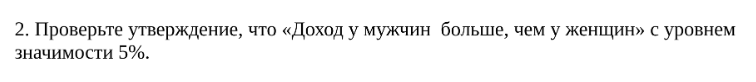

crit 1.4804918358731154 stat 1.0461673216725236 h0_accepted


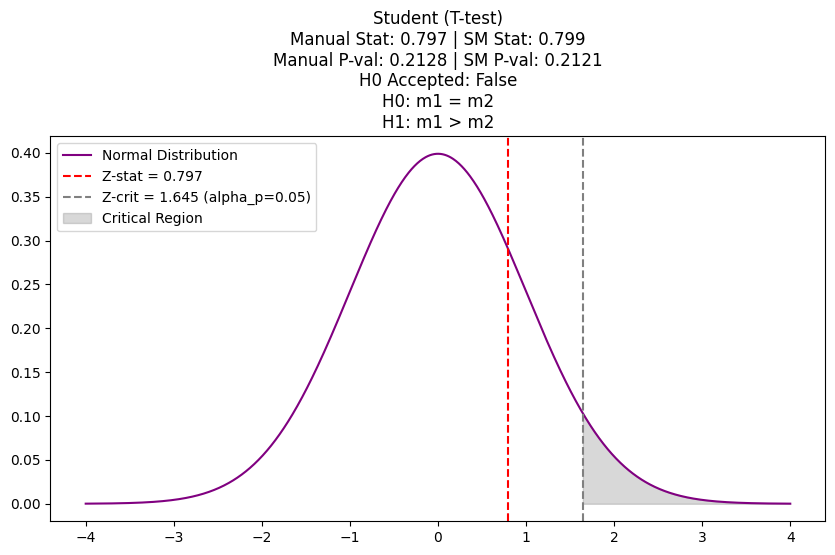

In [7]:
def get_gender_stats(param: str, var_ddof: int):
    gender_stats = []
    for g in ["Male", "Female"]:
        df = mall_df[mall_df["Genre"] == g]
        g_stat = {
            "gender": g,
            "n": df[param].count(),
            "var": df[param].var(ddof=var_ddof),
            "mean": df[param].mean()
        }
        gender_stats.append(g_stat)
    return gender_stats

income_gender_stats = get_gender_stats(param="Annual Income (k$)", var_ddof=0)
m_income = income_gender_stats[0]
f_income = income_gender_stats[1]


d_dof = 0
# 2. Distribute variances for F-test (F = S_max / S_min)
if m_income["var"] > f_income["var"]:
    f_stat = m_income["var"] / f_income["var"]
    # If ddof=0, df=n. If ddof=1, df=n-1
    df1, df2 = m_income["n"] - d_dof, f_income["n"] - d_dof
    bigger_var_gender = m_income["gender"]
else:
    f_stat = f_income["var"] / m_income["var"]
    df1, df2 = f_income["n"] - d_dof, m_income["n"] - d_dof
    bigger_var_gender = f_income["gender"]

# 3. Manual Critical Value and P-value
f_crit = stats.f.ppf(1 - ALPHA_P / 2, df1, df2)
h0_accepted = f_stat < f_crit
print(f"crit {f_crit} stat {f_stat} h0_accepted")

# Calculate Z
z_stat_income = (m_income["mean"] - f_income["mean"]) / sqrt(
    (m_income["var"] / m_income["n"])
    + (f_income["var"] / f_income["n"])
)

p_value_income = 1 - stats.norm.cdf(z_stat_income)
z_crit = stats.norm.ppf(1 - ALPHA_P)

h0_acceptance_income = z_stat_income > z_crit


male_income_raw = mall_df[mall_df["Genre"] == "Male"]["Annual Income (k$)"]
female_income_raw = mall_df[mall_df["Genre"] == "Female"]["Annual Income (k$)"]

z_stat_sm_income, p_value_sm_income = stm.ztest(
    male_income_raw, female_income_raw, alternative="larger", ddof=0
)


# Plot Normal distr
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

ax.plot(x, y, label="Normal Distribution", color="purple")
ax.set_title(
    f"{title}\n"
    f"Manual Stat: {z_stat_income:.3f} | SM Stat: {z_stat_sm_income:.3f}\n"
    f"Manual P-val: {p_value_income:.4f} | SM P-val: {p_value_sm_income:.4f}\n"
    f"H0 Accepted: {h0_acceptance_income}\n"
    f"H0: m1 = m2\n"
    f"H1: m1 > m2"

)

ax.axvline(
    z_stat_income, color="red", linestyle="--", label=f"Z-stat = {z_stat_income:.3f}"
)
ax.axvline(
    z_crit,
    color="grey",
    linestyle="--",
    label=f"Z-crit = {z_crit:.3f} (alpha_p={ALPHA_P})",
)

x_crit = np.linspace(z_crit, 4, 100)
ax.fill_between(
    x_crit, stats.norm.pdf(x_crit), color="grey", alpha=0.3, label="Critical Region"
)

ax.legend()
plt.show()

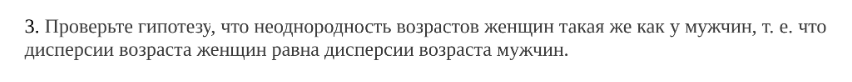

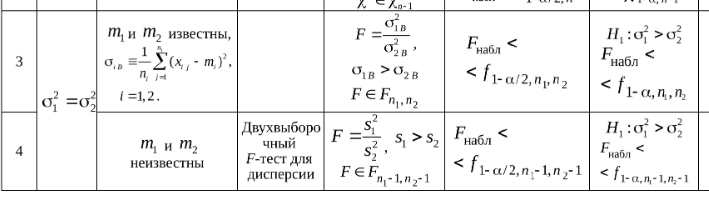

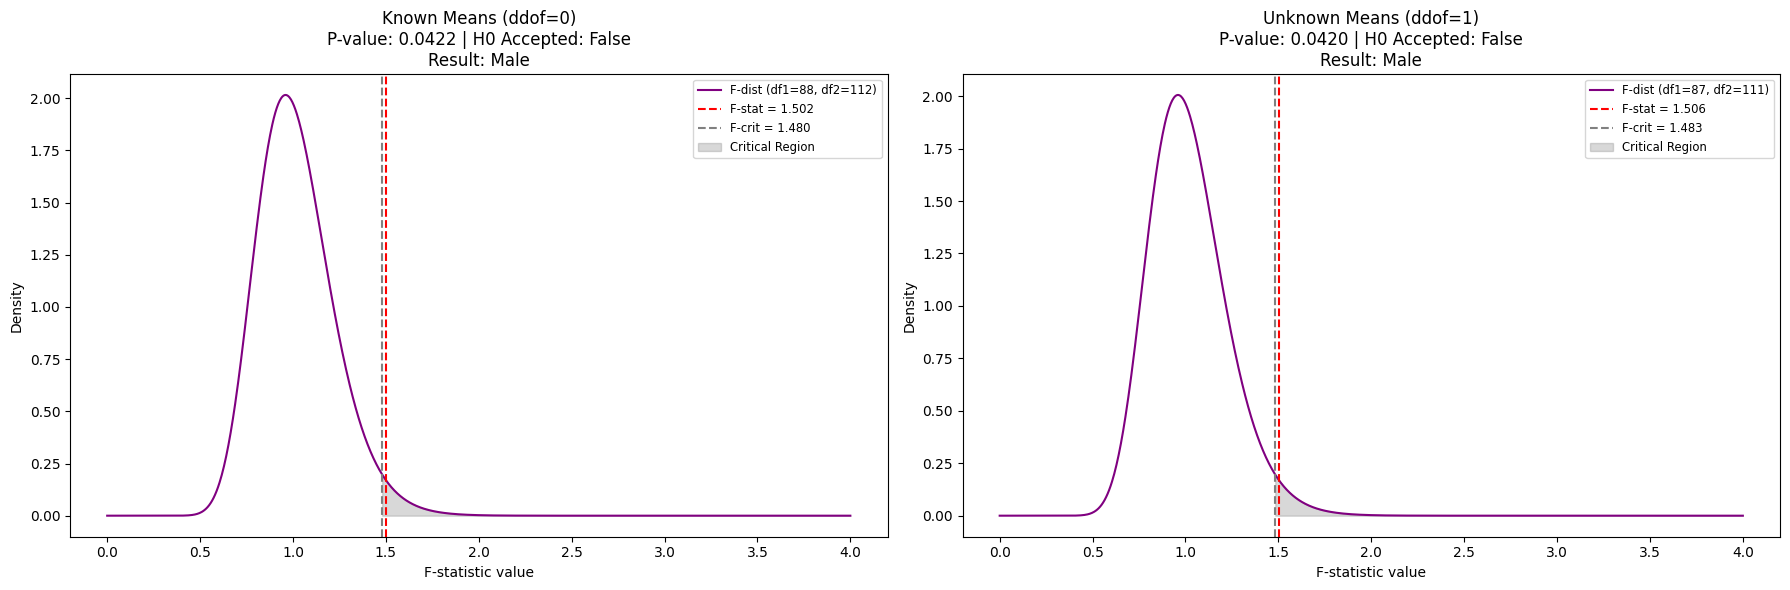

In [8]:
param = "Age"

# Prepare two axes for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Cases to iterate: (Title, ddof_value)
cases = [("Known Means (ddof=0)", 0), ("Unknown Means (ddof=1)", 1)]

for ax, (title, d_dof) in zip(axes, cases):
    # 1. Get stats using your function
    age_stats = get_gender_stats(param=param, var_ddof=d_dof)
    m_age = age_stats[0]
    f_age = age_stats[1]

    # 2. Distribute variances for F-test (F = S_max / S_min)
    if m_age["var"] > f_age["var"]:
        f_stat = m_age["var"] / f_age["var"]
        # If ddof=0, df=n. If ddof=1, df=n-1
        df1, df2 = m_age["n"] - d_dof, f_age["n"] - d_dof
        bigger_var_gender = m_age["gender"]
    else:
        f_stat = f_age["var"] / m_age["var"]
        df1, df2 = f_age["n"] - d_dof, m_age["n"] - d_dof
        bigger_var_gender = f_age["gender"]

    # 3. Manual Critical Value and P-value
    f_crit = stats.f.ppf(1 - ALPHA_P / 2, df1, df2)
    h0_accepted = f_stat < f_crit
    p_val_manual = 2 * stats.f.sf(f_stat, df1, df2)

    # 4. Visualization
    x = np.linspace(0, 4, 1000)
    y = stats.f.pdf(x, df1, df2)

    ax.plot(x, y, label=f"F-dist (df1={df1}, df2={df2})", color="purple")
    ax.axvline(f_stat, color="red", linestyle="--", label=f"F-stat = {f_stat:.3f}")
    ax.axvline(f_crit, color="grey", linestyle="--", label=f"F-crit = {f_crit:.3f}")

    # Shade critical region
    x_crit = np.linspace(f_crit, 4, 100)
    ax.fill_between(
        x_crit,
        stats.f.pdf(x_crit, df1, df2),
        color="grey",
        alpha=0.3,
        label="Critical Region",
    )

    # Labels and Title (including P-value for statsmodels comparison point)
    ax.set_title(
        f"{title}\n"
        f"P-value: {p_val_manual:.4f} | H0 Accepted: {h0_accepted}\n"
        f"Result: {'Equal' if h0_accepted else bigger_var_gender}"
    )
    ax.set_xlabel("F-statistic value")
    ax.set_ylabel("Density")
    ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

np.float64(28.022284817594368)

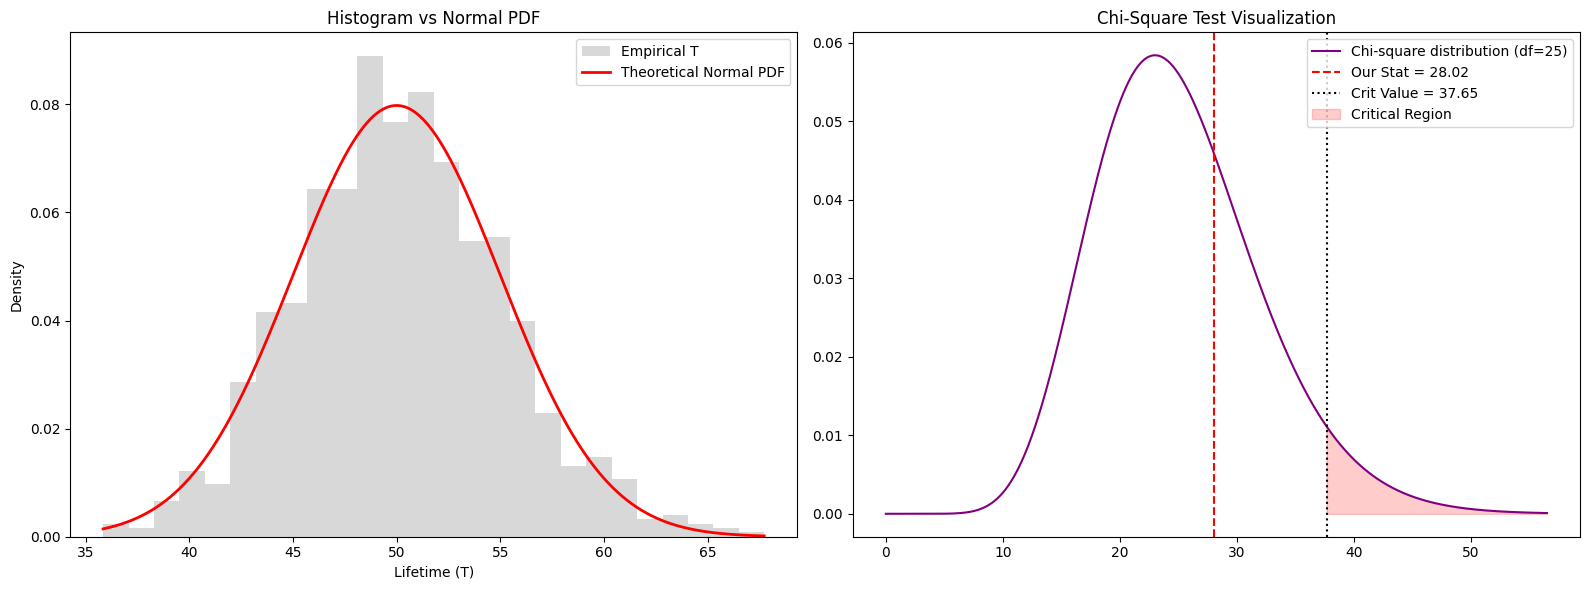

--- Theoretical Parameters ---
Mean (mu): 50.0
Std (sigma): 5.0

--- Chi-Square Test (Normal Dist) ---
Chi-Square Stat: 28.0223
Critical Value: 37.6525
P-value: 0.3068
Decision: H0 Accepted (Normal)


In [9]:
N_blades = 100
lambd = 2
n_samples = 1000
exp_mean = 1 / lambd
exp_var = 1 / lambd ** 2

norm_mean = N_blades * exp_mean
norm_std = sqrt(N_blades * exp_var)


blade_lifetimes = stats.expon.rvs(scale=exp_mean, size=(n_samples, N_blades))
T_samples = blade_lifetimes.sum(axis=1)

m_bins = int((3.78 * (n_samples - 1)) ** (2/5))

nj_vals, bins_edges  = np.histogram(T_samples, bins=m_bins)
pj_vals = stats.norm.cdf(
    bins_edges[1:], loc=norm_mean, scale=norm_std
) - stats.norm.cdf(bins_edges[:-1], loc=norm_mean, scale=norm_std)

# Normalize
pj_vals = pj_vals / pj_vals.sum()

expected_nj = n_samples * pj_vals
chi_sq_stat = np.sum((nj_vals - expected_nj) ** 2 / expected_nj)
display(chi_sq_stat)
df = m_bins - 1

z_crit_plane = stats.chi2.ppf(1 - ALPHA_P, df)
p_value = stats.chi2.sf(chi_sq_stat, df)

x_plot = np.linspace(T_samples.min(), T_samples.max(), 1000)
y_plot = stats.norm.pdf(x_plot, loc=norm_mean, scale=norm_std)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram + PDF line
ax1.hist(
    T_samples, bins=m_bins, density=True, color="grey", alpha=0.3, label="Empirical T"
)
ax1.plot(x_plot, y_plot, color="red", lw=2, label="Theoretical Normal PDF")
ax1.set_title("Histogram vs Normal PDF")
ax1.set_xlabel("Lifetime (T)")
ax1.set_ylabel("Density")
ax1.legend()

x_chi = np.linspace(0, z_crit_plane * 1.5, 1000)
y_chi = stats.chi2.pdf(x_chi, df)

ax2.plot(x_chi, y_chi, label=f"Chi-square distribution (df={df})", color="purple")
ax2.axvline(
    chi_sq_stat, color="red", linestyle="--", label=f"Our Stat = {chi_sq_stat:.2f}"
)
ax2.axvline(
    z_crit_plane, color="black", linestyle=":", label=f"Crit Value = {z_crit_plane:.2f}"
)

x_crit = np.linspace(z_crit_plane, x_chi[-1], 100)
ax2.fill_between(
    x_crit, stats.chi2.pdf(x_crit, df), color="red", alpha=0.2, label="Critical Region"
)

ax2.set_title("Chi-Square Test Visualization")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"--- Theoretical Parameters ---")
print(f"Mean (mu): {norm_mean}")
print(f"Std (sigma): {norm_std}")
print(f"\n--- Chi-Square Test (Normal Dist) ---")
print(f"Chi-Square Stat: {chi_sq_stat:.4f}")
print(f"Critical Value: {z_crit_plane:.4f}")
print(f"P-value: {p_value:.4f}")
print(
    f"Decision: {'H0 Accepted (Normal)' if chi_sq_stat < z_crit_plane else 'H0 Rejected'}"
)